<a href="https://colab.research.google.com/github/ryanchoigit/hyperbolicgat/blob/main/Step1_Data_Collection_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚀 HyperStockGAT - Step 1: Data Collection & Feature Engineering

This notebook collects historical stock price data and computes the 5 features
used in the HyperStockGAT paper:

1. **1-day return ratio**
2. **5-day moving average**
3. **10-day moving average**
4. **20-day moving average**
5. **30-day moving average**

Paper: [Exploring the Scale-Free Nature of Stock Markets (WWW 2021)](https://dl.acm.org/doi/10.1145/3442381.3450095)

---

## 0. Setup: Mount Drive & Install Dependencies

We store all data on Google Drive so it persists between Colab sessions.

In [ ]:
# Mount Google Drive for persistent storage
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Create project folder on Drive
import os

PROJECT_DIR = '/content/drive/MyDrive/hyperstockgat'
DATA_DIR = os.path.join(PROJECT_DIR, 'data')

os.makedirs(DATA_DIR, exist_ok=True)
print(f'Project directory: {PROJECT_DIR}')
print(f'Data directory: {DATA_DIR}')

Project directory: /content/drive/MyDrive/hyperstockgat
Data directory: /content/drive/MyDrive/hyperstockgat/data


In [ ]:
# Install dependencies
!pip install -q yfinance tqdm

import numpy as np
import pandas as pd
import yfinance as yf
import time
import json
from tqdm import tqdm
from datetime import datetime

print('All imports ready!')

All imports ready!


---
## 1. Configuration

Adjust these settings for your needs. Start with `MAX_STOCKS = 50` to test
the pipeline, then set to `None` for the full dataset.

In [ ]:
# ============================================================
# CONFIGURATION - Change these!
# ============================================================

MARKET = 'NASDAQ'  # Which market to collect

# Date range (extra buffer before 2019 for 30-day MA warm-up)
START_DATE = '2018-11-01'
END_DATE = '2024-12-31'
ANALYSIS_START = '2019-01-01'  # Actual start after warm-up

# Chronological splits
TRAIN_END = '2022-12-31'    # 4 years training
VAL_END = '2023-12-31'      # 1 year validation
# Test = 2024 (everything after VAL_END)

# Start small to validate, then set to None for full dataset
MAX_STOCKS = None  # <-- Change to None once pipeline works

print(f'Market: {MARKET}')
print(f'Period: {ANALYSIS_START} to {END_DATE}')
print(f'Max stocks: {MAX_STOCKS or "ALL"}')

Market: NASDAQ
Period: 2019-01-01 to 2024-12-31
Max stocks: ALL


---
## 2. Get Stock Tickers

We fetch the S&P 500 constituent list from Wikipedia as a starting point.
For a more complete NASDAQ list, you can replace this with a CSV from
NASDAQ's official site or the SEC EDGAR database.

In [ ]:
!pip install -q pandas_datareader

import pandas as pd

# Fetch S&P 500 list with a browser-like header so Wikipedia doesn't block us
url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
headers = {'User-Agent': 'Mozilla/5.0'}

import requests
resp = requests.get(url, headers=headers)
tables = pd.read_html(resp.text)
sp500_tickers = tables[0]['Symbol'].tolist()
sp500_tickers = [t.replace('.', '-') for t in sp500_tickers]

print(f'Fetched {len(sp500_tickers)} tickers')
print(f'First 10: {sp500_tickers[:10]}')

if MAX_STOCKS:
    tickers = sp500_tickers[:MAX_STOCKS]
else:
    tickers = sp500_tickers

print(f'Using {len(tickers)} tickers')

Fetched 503 tickers
First 10: ['MMM', 'AOS', 'ABT', 'ABBV', 'ACN', 'ADBE', 'AMD', 'AES', 'AFL', 'A']
Using 503 tickers


/tmp/ipython-input-708644186.py:11: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(resp.text)


---
## 3. Download Historical Prices

This downloads daily closing prices from Yahoo Finance via `yfinance`.
For 50 stocks this takes ~30 seconds. For 500+ stocks, a few minutes.

In [ ]:
print(f'Downloading prices for {len(tickers)} stocks...')
print(f'Period: {START_DATE} to {END_DATE}\n')

# Bulk download (much faster than one-by-one)
raw_data = yf.download(
    tickers,
    start=START_DATE,
    end=END_DATE,
    progress=True,
    threads=True
)

# Extract closing prices
if isinstance(raw_data.columns, pd.MultiIndex):
    close_prices = raw_data['Close']
else:
    close_prices = raw_data[['Close']]
    close_prices.columns = tickers[:1]

print(f'\nDownloaded: {close_prices.shape[0]} trading days × {close_prices.shape[1]} stocks')

Period: 2018-11-01 to 2024-12-31



/tmp/ipython-input-3893624059.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_data = yf.download(
[*********************100%***********************]  503 of 503 completed
ERROR:yfinance:
2 Failed downloads:
ERROR:yfinance:['Q', 'SNDK']: YFPricesMissingError('possibly delisted; no price data found  (1d 2018-11-01 -> 2024-12-31) (Yahoo error = "Data doesn\'t exist for startDate = 1541044800, endDate = 1735621200")')



Downloaded: 1549 trading days × 503 stocks


---
## 4. Clean the Data

Remove stocks with too much missing data, forward-fill small gaps.

In [ ]:
MAX_MISSING_PCT = 0.10  # Remove stocks missing more than 10% of days

print('Cleaning data...\n')

n_before = close_prices.shape[1]

# Check missing data per stock
missing_pct = close_prices.isnull().mean()
print('Stocks with most missing data:')
print(missing_pct.sort_values(ascending=False).head(10).to_string())
print()

# Remove stocks with too much missing data
valid_cols = missing_pct[missing_pct <= MAX_MISSING_PCT].index
close_prices = close_prices[valid_cols]
print(f'Removed {n_before - close_prices.shape[1]} stocks with >{MAX_MISSING_PCT*100}% missing data')

# Forward-fill small gaps
close_prices = close_prices.ffill()

# Drop remaining NaN rows (usually at the very start)
close_prices = close_prices.dropna()

tickers = list(close_prices.columns)
print(f'\nClean data: {close_prices.shape[0]} days × {len(tickers)} stocks')

Cleaning data...

Stocks with most missing data:
Ticker
SNDK    1.000000
Q       1.000000
GEV     0.876049
SOLV    0.875403
VLTO    0.798580
KVUE    0.730794
GEHC    0.669464
CEG     0.521627
HOOD    0.444158
APP     0.397030

Removed 18 stocks with >10.0% missing data

Clean data: 1398 days × 485 stocks


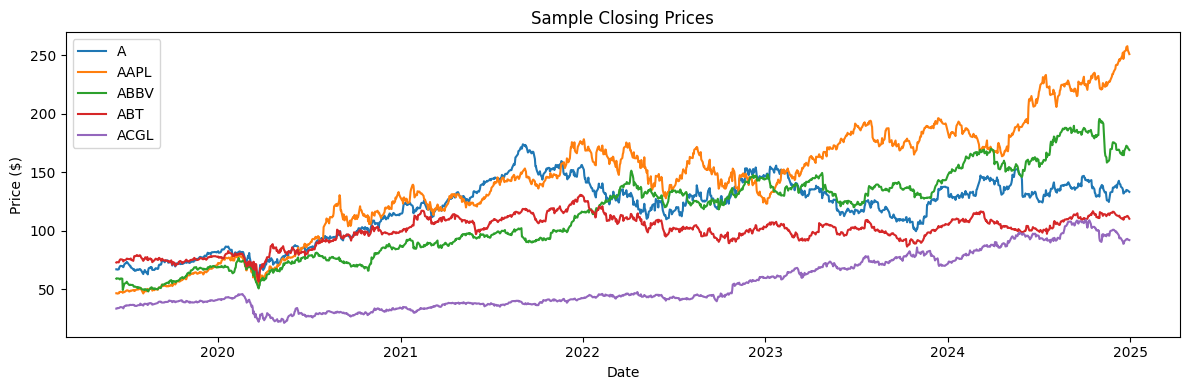

In [ ]:
# Quick sanity check: plot a few stocks
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4))
for t in tickers[:5]:
    ax.plot(close_prices.index, close_prices[t], label=t)
ax.set_title('Sample Closing Prices')
ax.set_xlabel('Date')
ax.set_ylabel('Price ($)')
ax.legend()
plt.tight_layout()
plt.show()

---
## 5. Compute the 5 Features

From the paper (Section 4.4):
- **Return Ratio**: `(price_t - price_{t-1}) / price_{t-1}`
- **MA@5, 10, 20, 30**: Moving averages normalized by current price

Output shape: `(N_stocks, N_days, 5)`

In [ ]:
print('Computing features...\n')

# Compute raw features
return_ratio = close_prices.pct_change()
ma_5 = close_prices.rolling(window=5).mean()
ma_10 = close_prices.rolling(window=10).mean()
ma_20 = close_prices.rolling(window=20).mean()
ma_30 = close_prices.rolling(window=30).mean()

# Trim to analysis period (after warm-up)
mask = close_prices.index >= ANALYSIS_START
return_ratio = return_ratio.loc[mask]
ma_5 = ma_5.loc[mask]
ma_10 = ma_10.loc[mask]
ma_20 = ma_20.loc[mask]
ma_30 = ma_30.loc[mask]
prices_trimmed = close_prices.loc[mask]

# Normalize MAs by current price (makes them scale-invariant)
ma_5_norm = ma_5 / prices_trimmed
ma_10_norm = ma_10 / prices_trimmed
ma_20_norm = ma_20 / prices_trimmed
ma_30_norm = ma_30 / prices_trimmed

# Drop rows with any NaN
valid = (
    return_ratio.notna().all(axis=1) &
    ma_5_norm.notna().all(axis=1) &
    ma_10_norm.notna().all(axis=1) &
    ma_20_norm.notna().all(axis=1) &
    ma_30_norm.notna().all(axis=1)
)

dates = prices_trimmed.index[valid]
return_ratio = return_ratio.loc[valid]
ma_5_norm = ma_5_norm.loc[valid]
ma_10_norm = ma_10_norm.loc[valid]
ma_20_norm = ma_20_norm.loc[valid]
ma_30_norm = ma_30_norm.loc[valid]

# Stack into (N_stocks, N_days, 5) numpy array
N_stocks = len(tickers)
N_days = len(dates)

features = np.zeros((N_stocks, N_days, 5))
for i, ticker in enumerate(tickers):
    features[i, :, 0] = return_ratio[ticker].values
    features[i, :, 1] = ma_5_norm[ticker].values
    features[i, :, 2] = ma_10_norm[ticker].values
    features[i, :, 3] = ma_20_norm[ticker].values
    features[i, :, 4] = ma_30_norm[ticker].values

print(f'Feature tensor shape: {features.shape}')
print(f'  → {N_stocks} stocks × {N_days} days × 5 features')
print(f'  → Date range: {dates[0].strftime("%Y-%m-%d")} to {dates[-1].strftime("%Y-%m-%d")}')
print(f'  → Features: [return_ratio, MA@5, MA@10, MA@20, MA@30]')

Computing features...

Feature tensor shape: (485, 1369, 5)
  → 485 stocks × 1369 days × 5 features
  → Date range: 2019-07-24 to 2024-12-30
  → Features: [return_ratio, MA@5, MA@10, MA@20, MA@30]


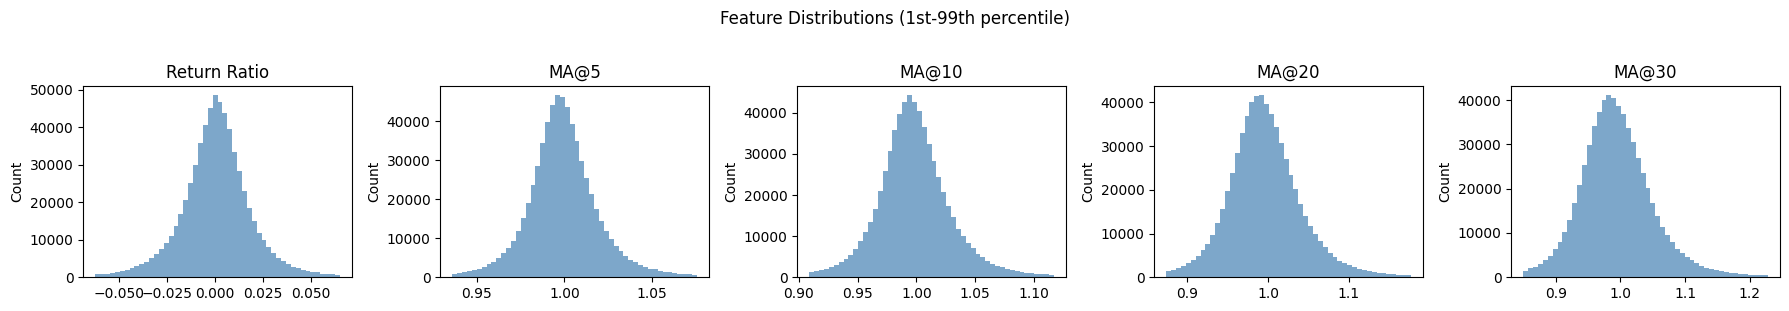

In [ ]:
# Sanity check: feature distributions
feature_names = ['Return Ratio', 'MA@5', 'MA@10', 'MA@20', 'MA@30']

fig, axes = plt.subplots(1, 5, figsize=(18, 3))
for i, (ax, name) in enumerate(zip(axes, feature_names)):
    vals = features[:, :, i].flatten()
    # Clip outliers for visualization
    low, high = np.percentile(vals, [1, 99])
    vals_clipped = vals[(vals >= low) & (vals <= high)]
    ax.hist(vals_clipped, bins=50, alpha=0.7, color='steelblue')
    ax.set_title(name)
    ax.set_ylabel('Count')
plt.suptitle('Feature Distributions (1st-99th percentile)', y=1.02)
plt.tight_layout()
plt.show()

---
## 6. Train / Validation / Test Split

Following chronological splits:
- **Train**: Jan 2019 – Dec 2022 (~4 years)
- **Validation**: Jan 2023 – Dec 2023 (~1 year)
- **Test**: Jan 2024 – Dec 2024 (~1 year)

In [ ]:
train_mask = dates <= pd.Timestamp(TRAIN_END)
val_mask = (dates > pd.Timestamp(TRAIN_END)) & (dates <= pd.Timestamp(VAL_END))
test_mask = dates > pd.Timestamp(VAL_END)

train_features = features[:, train_mask, :]
val_features = features[:, val_mask, :]
test_features = features[:, test_mask, :]

train_dates = dates[train_mask]
val_dates = dates[val_mask]
test_dates = dates[test_mask]

print('Split summary:')
print(f'  Train: {train_features.shape[1]:>4} days  ({train_dates[0].strftime("%Y-%m-%d")} → {train_dates[-1].strftime("%Y-%m-%d")})')
print(f'  Val:   {val_features.shape[1]:>4} days  ({val_dates[0].strftime("%Y-%m-%d")} → {val_dates[-1].strftime("%Y-%m-%d")})')
print(f'  Test:  {test_features.shape[1]:>4} days  ({test_dates[0].strftime("%Y-%m-%d")} → {test_dates[-1].strftime("%Y-%m-%d")})')

# Compare with expected approximate counts
print(f'\nExpected roughly: ~1008 / ~252 / ~252 days')
print(f'We got:           {train_features.shape[1]} / {val_features.shape[1]} / {test_features.shape[1]} days')

Split summary:
  Train:  868 days  (2019-07-24 → 2022-12-30)
  Val:    250 days  (2023-01-03 → 2023-12-29)
  Test:   251 days  (2024-01-02 → 2024-12-30)

Expected roughly: ~1008 / ~252 / ~252 days
We got:           868 / 250 / 251 days


---
## 7. Save Everything to Google Drive

This saves all data so you can load it in future notebooks without
re-downloading.

# New Section

In [ ]:
print(f'Saving to {DATA_DIR}/\n')

# Feature arrays
np.save(os.path.join(DATA_DIR, 'train_features.npy'), train_features)
np.save(os.path.join(DATA_DIR, 'val_features.npy'), val_features)
np.save(os.path.join(DATA_DIR, 'test_features.npy'), test_features)
np.save(os.path.join(DATA_DIR, 'all_features.npy'), features)

# Metadata
pd.DataFrame({'ticker': tickers}).to_csv(
    os.path.join(DATA_DIR, 'tickers.csv'), index=False
)
pd.DataFrame({'date': dates}).to_csv(
    os.path.join(DATA_DIR, 'dates.csv'), index=False
)

# Closing prices (needed later for computing returns during evaluation)
prices_for_eval = close_prices.loc[close_prices.index.isin(dates)]
prices_for_eval.to_csv(os.path.join(DATA_DIR, 'closing_prices.csv'))

# Save data summary
summary = {
    'market': MARKET,
    'n_stocks': N_stocks,
    'n_days': N_days,
    'n_features': 5,
    'features': ['return_ratio', 'MA@5', 'MA@10', 'MA@20', 'MA@30'],
    'train_days': int(train_mask.sum()),
    'val_days': int(val_mask.sum()),
    'test_days': int(test_mask.sum()),
    'start_date': dates[0].strftime('%Y-%m-%d'),
    'end_date': dates[-1].strftime('%Y-%m-%d'),
    'tickers_sample': tickers[:10],
}

with open(os.path.join(DATA_DIR, 'data_summary.json'), 'w') as f:
    json.dump(summary, f, indent=2)

# Print what was saved
print('Saved files:')
for fname in sorted(os.listdir(DATA_DIR)):
    fpath = os.path.join(DATA_DIR, fname)
    size_kb = os.path.getsize(fpath) / 1024
    print(f'  {fname:<25} {size_kb:>8.1f} KB')

Saving to /content/drive/MyDrive/hyperstockgat/data/

Saved files:
  all_features.npy           25936.3 KB
  closing_prices.csv         11798.0 KB
  data_summary.json              0.4 KB
  dates.csv                     14.7 KB
  test_features.npy           4755.4 KB
  tickers.csv                    2.0 KB
  train_features.npy         16444.7 KB
  val_features.npy            4736.5 KB


---
## 8. Verify: Load and Check Saved Data

Quick test to make sure everything loads correctly from Drive.
This is exactly how you'll load data in future notebooks.

In [ ]:
# This is how you'll load data in Step 2, 3, etc.
loaded_train = np.load(os.path.join(DATA_DIR, 'train_features.npy'))
loaded_tickers = pd.read_csv(os.path.join(DATA_DIR, 'tickers.csv'))['ticker'].tolist()

with open(os.path.join(DATA_DIR, 'data_summary.json'), 'r') as f:
    loaded_summary = json.load(f)

print('Loaded successfully!')
print(f'  Train features shape: {loaded_train.shape}')
print(f'  Number of tickers: {len(loaded_tickers)}')
print(f'  Summary: {json.dumps(loaded_summary, indent=2)}')

Loaded successfully!
  Train features shape: (485, 868, 5)
  Number of tickers: 485
  Summary: {
  "market": "NASDAQ",
  "n_stocks": 485,
  "n_days": 1369,
  "n_features": 5,
  "features": [
    "return_ratio",
    "MA@5",
    "MA@10",
    "MA@20",
    "MA@30"
  ],
  "train_days": 868,
  "val_days": 250,
  "test_days": 251,
  "start_date": "2019-07-24",
  "end_date": "2024-12-30",
  "tickers_sample": [
    "A",
    "AAPL",
    "ABBV",
    "ABT",
    "ACGL",
    "ACN",
    "ADBE",
    "ADI",
    "ADM",
    "ADP"
  ]
}


---
## ✅ Done! Next Steps

Your data is saved to Google Drive at:
```
drive/MyDrive/hyperstockgat/data/
```

### What to do next:

1. **If MAX_STOCKS was 50**: Go back to the config cell, set `MAX_STOCKS = None`,
   and re-run the whole notebook to get the full dataset.

2. **Step 2 (next notebook)**: Build the stock relation graph
   - Query Wikidata for corporate relations (57 property types)
   - Look up GICS codes for industry relations
   - Construct adjacency matrix

3. **Step 3**: Implement the HyperStockGAT model in PyTorch

4. **Step 4**: Train and evaluate

### Project structure on Drive:
```
drive/MyDrive/hyperstockgat/
├── data/
│   ├── train_features.npy
│   ├── val_features.npy
│   ├── test_features.npy
│   ├── all_features.npy
│   ├── tickers.csv
│   ├── dates.csv
│   ├── closing_prices.csv
│   └── data_summary.json
├── Step1_Data_Collection.ipynb    ← this notebook
├── Step2_Graph_Construction.ipynb  ← next
├── Step3_Model.ipynb              ← later
└── Step4_Train_Evaluate.ipynb     ← later
```